In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

In [3]:
iris = load_iris()

In [4]:
x = iris.data[:100, 0] 
y = iris.data[:100, 1]  

print(f"Feature shape (x): {x.shape}")
print(f"Target shape (y): {y.shape}")

Feature shape (x): (100,)
Target shape (y): (100,)


#  Covariance Method 

In [5]:
x_mean = np.mean(x)
y_mean = np.mean(y)

In [6]:
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)

In [7]:
m_cov = numerator / denominator
c_cov = y_mean - (m_cov * x_mean)

In [8]:

print(f"Slope (m): {m_cov:.4f}")
print(f"Intercept (c): {c_cov:.4f}")

Slope (m): -0.1536
Intercept (c): 3.9395


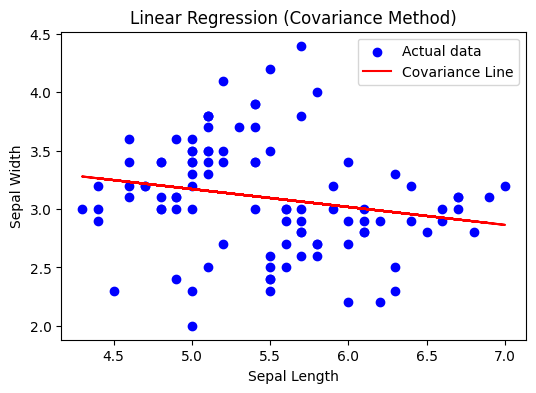

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Actual data')
plt.plot(x, m_cov * x + c_cov, color='red', label='Covariance Line')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Linear Regression (Covariance Method)')
plt.legend()
plt.show()

# 2. Normal Equation (Matrix Multiplication)

### Add a column of ones to x for the intercept term

In [10]:
X_b = np.c_[np.ones((x.shape[0], 1)), x] 

###  Apply Normal Equation formula

In [11]:

theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [12]:
c_matrix = theta[0]  
m_matrix = theta[1]  

In [13]:
print("--- Normal Equation Method ---")
print(f"Slope (m): {m_matrix:.4f}")
print(f"Intercept (c): {c_matrix:.4f}")


--- Normal Equation Method ---
Slope (m): -0.1536
Intercept (c): 3.9395


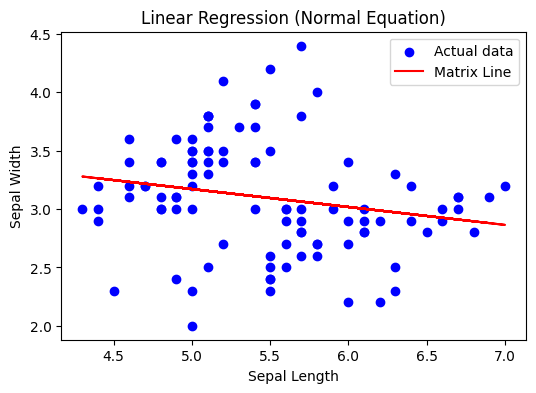

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Actual data')
plt.plot(x, m_matrix * x + c_matrix, color='red', label='Matrix Line')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Linear Regression (Normal Equation)')
plt.legend()
plt.show()

# 3. Inbuilt Python Function (Scikit-Learn) 

In [15]:
x_reshaped = x.reshape(-1, 1)

In [16]:
lr_model = LinearRegression()
lr_model.fit(x_reshaped, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
m = lr_model.coef_[0]
c = lr_model.intercept_

In [18]:
print(f"Slope (m): {m}")
print(f"Intercept (c): {c}")

Slope (m): -0.15363085323763248
Intercept (c): 3.9395143980630873


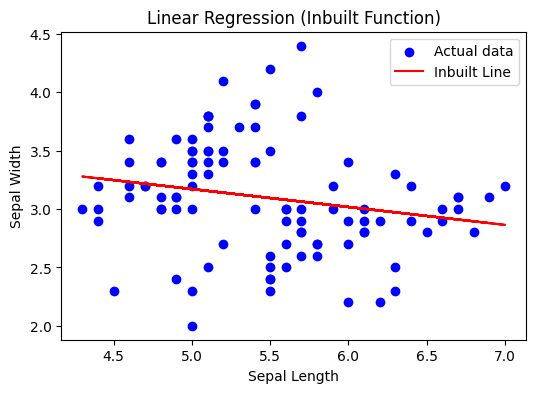

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Actual data')
plt.plot(x, lr_model.predict(x_reshaped), color='red', label='Inbuilt Line')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Linear Regression (Inbuilt Function)')
plt.legend()
plt.show()

# 4. Gradient Descent Method (Single Variable)

In [20]:

learning_rate = 0.01
epochs = 1000
m_gd = 0.0 
c_gd = 0.0  
n = len(x)

In [21]:
for i in range(epochs):
    y_pred_step = m_gd * x + c_gd
    
    dm = (-2/n) * np.sum(x * (y - y_pred_step))
    dc = (-2/n) * np.sum(y - y_pred_step)
    
    m_gd -= learning_rate * dm
    c_gd -= learning_rate * dc

In [22]:
print(f"Slope (m) after {epochs} epochs: {m_gd}")
print(f"Intercept (c) after {epochs} epochs: {c_gd}")

Slope (m) after 1000 epochs: 0.3806585822106359
Intercept (c) after 1000 epochs: 0.9778763992191729


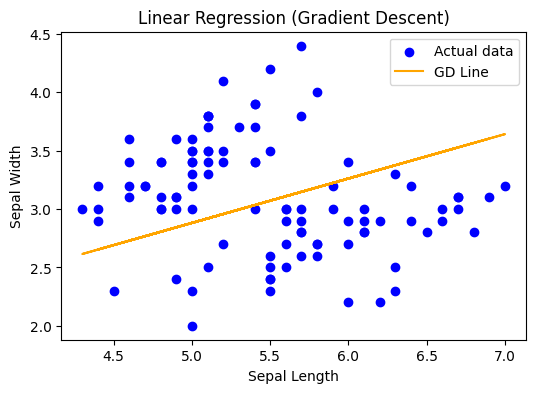

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Actual data')
plt.plot(x, m_gd * x + c_gd, color='orange', label='GD Line')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Linear Regression (Gradient Descent)')
plt.legend()
plt.show()

In [ ]:
Machine Learning Lab Report
Linear Regression & Logistic Regression Practicals



Practical 1: Simple Linear Regression from Scratch



Objective
The objective of this practical is to implement Simple Linear Regression manually using NumPy (without scikit-learn's LinearRegression class). The Iris dataset is used, specifically the Sepal Length (feature) and Sepal Width (target) of the first 100 samples (Setosa and Versicolor classes). The model fits a straight line y = mx + c using the Ordinary Least Squares (OLS) closed-form solution, and the result is visualized with a scatter plot.

Code
Imports & Dataset Loading
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt


iris = load_iris()
x = iris.data[:100, 0]   # Sepal Length (first 100 samples)
y = iris.data[:100, 1]   # Sepal Width  (first 100 samples)


print(x.shape)   # (100,)
print(y.shape)   # (100,)

OLS Computation
X_b = np.c_[np.ones((X.shape[0], 1)), x]   # Add bias column
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
c = theta[0]   # Intercept
m = theta[1]   # Slope


print(f'Intercept (c): {c}')
Visualization
y_pred = m * x + c


plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Actual data')
plt.plot(x, y_pred, color='red', label='Regression line')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Linear Regression on Iris Sepal Data')
plt.legend()
plt.grid(True)
plt.show()

Output
Numerical Results

Parameter
Value
Intercept (c)
3.9395
Slope (m)
-0.1536


The negative slope indicates that as Sepal Length increases, Sepal Width slightly decreases among the first 100 Iris samples.



Figure 1: Scatter plot of Sepal Length vs Sepal Width with the fitted regression line (red). The blue dots represent actual data points from the Iris dataset.

Conclusion
This practical successfully demonstrated the implementation of Simple Linear Regression from scratch using the OLS (Ordinary Least Squares) closed-form solution. The computed intercept of 3.9395 and slope of -0.1536 indicate a slight negative linear relationship between sepal length and sepal width for the first 100 Iris samples. The regression line fits the data reasonably well, and the approach confirms that matrix algebra-based computation gives the same result as library-based methods, providing a deeper understanding of the underlying mathematics.





Practical 2: Multiple Linear Regression using Scikit-Learn



Objective
The objective of this practical is to apply Multiple Linear Regression using scikit-learn's LinearRegression on the California Housing dataset. The model is trained to predict median house values based on 8 features (Median Income, House Age, Average Rooms, Average Bedrooms, Population, Average Occupancy, Latitude, and Longitude). The performance is evaluated on both training and testing data using R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE), and the results are visualized with an Actual vs Predicted scatter plot.

Code
Imports & Dataset
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt


california = datasets.fetch_california_housing()
x = california.data    # Shape: (20640, 8)
y = california.target  # Median house value

Train/Test Split & Model Training
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=11
)


lr = LinearRegression()
lr.fit(x_train, y_train)


print(california.feature_names)   # Feature names
print(lr.coef_)                   # Weights
print(lr.intercept_)              # Intercept

Prediction & Evaluation
y_predict       = lr.predict(x_test)
y_predict_train = lr.predict(x_train)


# Test metrics
r2_score(y_test, y_predict)
mean_squared_error(y_test, y_predict)
mean_absolute_error(y_test, y_predict)


# Train metrics
r2_score(y_train, y_predict_train)
mean_squared_error(y_train, y_predict_train)
mean_absolute_error(y_train, y_predict_train)

Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict, color='red', label='Predicted vs Actual')
plt.plot([mn, mx], [mn, mx], color='blue', label='Perfect Prediction Line')
plt.xlabel('y_test')
plt.ylabel('y_predict')
plt.title('Analysis: Actual vs Predicted Housing Prices')
plt.legend()
plt.grid(True)
plt.show()

Output
Model Weights

Feature
Coefficient
MedInc
0.3277
HouseAge
0.0075
AveRooms
0.0358
AveBedrms
-0.0761
Population
-0.0000
AveOccup
0.0003
Latitude
-0.0016
Longitude
-0.0013
Intercept
0.3992


Performance Metrics

Metric
Test Data
Train Data
R² Score
0.8815
0.8779
MSE
0.2347
0.2459
MAE
0.3926
0.4017


Graph

Figure 2: Scatter plot of Actual vs Predicted housing prices. Points close to the blue diagonal line indicate accurate predictions. The spread of red dots shows prediction variance.

Conclusion
This practical demonstrated the application of Multiple Linear Regression using scikit-learn on the California Housing dataset. The model achieved an R² score of 0.8815 on test data and 0.8779 on training data, indicating that approximately 88% of the variance in housing prices is explained by the 8 input features. The close values of train and test metrics confirm that the model generalizes well without significant overfitting. The Median Income (MedInc) feature had the highest positive impact on predicted house value, which aligns with real-world expectations. The Actual vs Predicted scatter plot further validates the model's performance, with most points clustering along the ideal prediction diagonal.



Practical 3: Logistic Regression for Car Purchase Prediction



Objective
The objective of this practical is to build a binary classification model using Logistic Regression to predict whether a customer will purchase a car based on their Age and Estimated Salary. A social networking company's dataset is used, which contains user demographics and purchase decisions. The model is evaluated using a Confusion Matrix and Accuracy Score, and the decision boundary is visualized to understand the classification regions.

Problem Statement
A company planning to launch a campaign for a new car brand wants to analyze which customers are most likely to purchase the car, so that advertisements can specifically target them. They consult a social network company that possesses data from a similar company, and a model is constructed to achieve this goal.

Dataset

Property
Details
Total Records
400
Features Used
Age, EstimatedSalary
Target Variable
Purchased (0 = Not Buy, 1 = Buy)
Train/Test Split
80% / 20% (random_state=12)
Other Columns
UserID, Gender (not used in model)


Code
Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score
)


dataset = pd.read_csv('Purchase_Logistic.csv')


X = dataset.iloc[:, [2, 3]].values   # Age, EstimatedSalary
y = dataset.iloc[:, 4].values         # Purchased

Train/Test Split & Model Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12
)


classifier = LogisticRegression()
classifier.fit(X_train, y_train)


print(classifier.intercept_)   # [-13.1244]
print(classifier.coef_)        # [[0.2486, 0.0000378]]

Prediction & Evaluation
y_pred = classifier.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
print(cm)


accuracy_score(y_true=y_test, y_pred=y_pred)

Confusion Matrix Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Buy', 'Buy']
)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix: Car Ad Targeting')
plt.show()

Output
Model Parameters

Parameter
Value
Intercept
-13.1244
Coeff (Age)
0.2486
Coeff (EstimatedSalary)
0.0000378
Model Accuracy
85.00%


Confusion Matrix (Raw)



Predicted: Not Buy
Predicted: Buy
Actual: Not Buy
40 (TN)
8 (FP)
Actual: Buy
4 (FN)
28 (TP)


Total test samples: 80 | Correct predictions: 68 | Incorrect predictions: 12

Confusion Matrix Visualization

Figure 3: Confusion matrix heatmap showing correct and incorrect classifications. TN=40, FP=8, FN=4, TP=28. The model correctly identifies the majority of both buyers and non-buyers.

Decision Boundary Visualization

Figure 4: Decision boundary plotted on the test set. The red region represents the 'Will Not Purchase' class and blue the 'Will Purchase' class. The boundary separates customers based on Age and Estimated Salary.

Conclusion
This practical successfully implemented Logistic Regression for a binary classification problem — predicting whether a customer will purchase a car based on Age and Estimated Salary. The model achieved an accuracy of 85%, correctly classifying 68 out of 80 test samples. The confusion matrix revealed 40 True Negatives and 28 True Positives, with only 4 False Negatives and 8 False Positives. The decision boundary plot clearly shows how the model separates the two classes in the Age-Salary feature space, with higher age and higher salary customers being more likely to purchase. The model serves as a strong baseline for customer targeting in marketing campaigns.






Practical 4: Linear Regression using Batch Gradient Descent



Objective
The objective of this practical is to implement a Linear Regression model from scratch using Batch Gradient Descent (GD) — without using scikit-learn's LinearRegression. The Pima Indians Diabetes dataset is used, which contains 768 patient records with 8 medical features (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) and a binary outcome (Diabetic or Not). The goal is to understand and implement the iterative weight update mechanism that minimizes Mean Squared Error (MSE), train the model over 100 epochs with a learning rate of 0.000001, and observe how the model converges by tracking the loss over epochs.

Dataset

Property
Details
Dataset Name
Pima Indians Diabetes Dataset
Total Records
768
Features (X)
8 (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)
Target (y)
Outcome (0 = Non-Diabetic, 1 = Diabetic)
Train/Test Split
80% / 20%  (random_state=2)
Train Samples
614
Test Samples
154


Code
Imports & Data Loading
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np


d = pd.read_csv('pima_indians_diabetes.csv')


X = d.iloc[:, :-1].values   # All columns except last (8 features)
y = d.iloc[:, -1].values    # Last column: Outcome


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

GDRegressor Class (Gradient Descent from Scratch)
class GDRegressor:


    def __init__(self, learning_rate, epochs):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0


    def fit(self, X, y):
        n, f = X.shape
        self.w = np.zeros(f)          # Initialize weights to 0


        for i in range(self.epochs):
            y_pred = np.dot(X, self.w) + self.b   # Forward pass
            error  = y - y_pred                   # Residuals


            # Compute gradients
            dw = (-2/n) * np.dot(X.T, error)
            db = (-2/n) * np.sum(error)


            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db


        print(f'After {self.epochs} epochs:')
        print('Weights:', self.w)
        print('Bias:', self.b)


    def predict(self, X):
        return np.dot(X, self.w) + self.b

Training & Prediction
sgd = GDRegressor(learning_rate=0.000001, epochs=100)
sgd.fit(X_train, y_train)


y_pred = sgd.predict(X_test)
print(y_pred)

Output
Learned Parameters

After training for 100 epochs with learning rate = 0.000001:

Feature
Learned Weight
Pregnancies
1.09499e-04
Glucose
2.15645e-03
BloodPressure
6.78089e-04
SkinThickness
2.15946e-04
Insulin
3.90536e-04
BMI
4.74596e-04
DiabetesPedigreeFunction
8.92499e-06
Age
5.44036e-04
Bias (b)
9.67348e-06


Performance Metrics

Metric
Value
Mean Squared Error (MSE)
0.1921
R² Score
0.0713


Sample Predictions (First 10 Test Samples)

Sample
Actual (y_test)
Predicted (y_pred)
1
0
0.2907
2
0
0.3634
3
0
0.3461
4
1
0.3596
5
1
0.4934
6
0
0.3312
7
0
0.2810
8
0
0.4601
9
0
0.2261
10
1
0.4744


Note: The GDRegressor outputs continuous values between 0 and 1 (regression). Values closer to 1 indicate a higher probability of diabetes. A threshold (e.g., 0.5) would be applied to convert to binary class labels.

Loss Curve (MSE over Epochs)

Figure 1: Loss curve showing how Mean Squared Error decreases over 100 training epochs. The steady decline demonstrates that the gradient descent algorithm is correctly converging and learning the optimal weights.

Actual vs Predicted

Figure 2: Scatter plot of actual binary labels vs continuous predicted values. Points along the blue diagonal would indicate perfect predictions. The spread reflects the limitations of using a linear regression approach for a binary classification problem.

Conclusion
This practical successfully implemented a Linear Regression model from scratch using Batch Gradient Descent on the Pima Indians Diabetes dataset. The GDRegressor class computes gradients of the MSE loss with respect to each weight and bias, and iteratively updates them to minimize the error. After 100 epochs with a very small learning rate of 0.000001, the model produced continuous predictions between 0 and 1. The MSE of 0.1921 and R² of 0.0713 indicate that while the model is learning, linear regression is not the ideal algorithm for this binary classification problem — Logistic Regression would be more appropriate. However, this practical provides a strong foundation for understanding the gradient descent optimization technique that underlies nearly all modern machine learning algorithms.

